In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('processed_spotify.csv')
df.head()

,track_id,track_name,artist_name,album_name,release_date,duration_ms,popularity,danceability,energy,key,...,key_name_C,key_name_C#,key_name_D,key_name_D#,key_name_E,key_name_F,key_name_F#,key_name_G,key_name_G#,mode_name_Minor
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,169594,0.510870,0.6777,0.7949,9,...,0,0,0,0,0,0,0,0,0,0
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,256755,0.282609,0.9405,0.7163,1,...,0,1,0,0,0,0,0,0,0,0
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,170212,0.500000,0.6853,0.9500,4,...,0,0,0,0,1,0,0,0,0,0
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,181250,0.043478,0.7817,0.6943,6,...,0,0,0,0,0,0,1,0,0,0
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,160894,0.293478,0.7200,0.4958,1,...,0,1,0,0,0,0,0,0,0,0


In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.columns.tolist()

['track_id',
 'track_name',
 'artist_name',
 'album_name',
 'release_date',
 'duration_ms',
 'popularity',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'instrumentalness',
 'tempo',
 'stream_count',
 'explicit',
 'label',
 'release_year',
 'release_month',
 'release_day_of_week',
 'duration_minutes',
 'popularity_category',
 'loudness_category',
 'is_explicit_bool',
 'release_quarter',
 'is_weekend_release',
 'log_stream_count',
 'upbeat_score',
 'artist_track_count',
 'genre_Alternative',
 'genre_Classical',
 'genre_Country',
 'genre_Disco',
 'genre_EDM',
 'genre_Folk',
 'genre_Hip-Hop',
 'genre_Indie',
 'genre_Jazz',
 'genre_K-Pop',
 'genre_Latin',
 'genre_Metal',
 'genre_Pop',
 'genre_Punk',
 'genre_R&B',
 'genre_Reggaeton',
 'genre_Rock',
 'genre_Soul',
 'genre_Trap',
 'country_AU',
 'country_BR',
 'country_CA',
 'country_CL',
 'country_CO',
 'country_DE',
 'country_EG',
 'country_ES',
 'country_FR',
 'country_GB',
 'country_ID',
 'country_IN',
 'country_IT',
 'countr

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('processed_spotify.csv')

In [3]:
df.head()

,track_id,track_name,artist_name,album_name,release_date,duration_ms,popularity,danceability,energy,key,...,key_name_C,key_name_C#,key_name_D,key_name_D#,key_name_E,key_name_F,key_name_F#,key_name_G,key_name_G#,mode_name_Minor
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,169594,0.510870,0.6777,0.7949,9,...,0,0,0,0,0,0,0,0,0,0
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,256755,0.282609,0.9405,0.7163,1,...,0,1,0,0,0,0,0,0,0,0
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,170212,0.500000,0.6853,0.9500,4,...,0,0,0,0,1,0,0,0,0,0
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,181250,0.043478,0.7817,0.6943,6,...,0,0,0,0,0,0,1,0,0,0
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,160894,0.293478,0.7200,0.4958,1,...,0,1,0,0,0,0,0,0,0,0


In [4]:
y = df['popularity']

In [5]:
#Определяем признаки (X), убирая целевую переменную и явные утечки/текст
columns_to_drop = [
    'popularity', 'track_id', 'track_name', 'artist_name', 'album_name', 
    'release_date', 'popularity_category', 'stream_count', 'log_stream_count'
]

X = df.drop(columns=columns_to_drop)

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Размер обучающей выборки: (35000, 80)
Размер тестовой выборки: (7500, 80)
Размер валидационной выборки: (7500, 80)


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем датасет
df = pd.read_csv('processed_spotify.csv')

# Применяем One-Hot Encoding к оставшимся текстовым колонкам
# label — название лейбла, release_day_of_week, release_quarter, loudness_category
columns_to_encode = ['label', 'release_day_of_week', 'release_quarter', 'loudness_category']
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

print("Размер датасета после one-hot encoding:", df_encoded.shape)
df_encoded.head()

Размер датасета после one-hot encoding: (50000, 125)


,track_id,track_name,artist_name,album_name,release_date,duration_ms,popularity,danceability,energy,key,...,release_day_of_week_Saturday,release_day_of_week_Sunday,release_day_of_week_Thursday,release_day_of_week_Tuesday,release_day_of_week_Wednesday,release_quarter_Q2,release_quarter_Q3,release_quarter_Q4,loudness_category_Moderate,loudness_category_Quiet
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,169594,0.510870,0.6777,0.7949,9,...,0,0,0,0,1,0,0,1,0,0
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,256755,0.282609,0.9405,0.7163,1,...,1,0,0,0,0,0,0,1,1,0
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,170212,0.500000,0.6853,0.9500,4,...,1,0,0,0,0,0,0,1,0,0
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,181250,0.043478,0.7817,0.6943,6,...,0,0,0,0,0,1,0,0,1,0
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,160894,0.293478,0.7200,0.4958,1,...,0,0,0,0,0,0,0,0,1,0


In [12]:
# Целевая переменная
y = df_encoded['popularity']

# Убираем целевую переменную, текстовые идентификаторы и утечки
columns_to_drop = [
    'popularity', 'track_id', 'track_name', 'artist_name', 'album_name', 
    'release_date', 'popularity_category', 'stream_count', 'log_stream_count'
]

X = df_encoded.drop(columns=columns_to_drop)

# Проверяем, что не осталось строковых колонок
print("Строковые колонки:", X.select_dtypes(include=['object']).columns.tolist())
print("Размер X:", X.shape)

Строковые колонки: []
Размер X: (50000, 116)


In [13]:
# Применяем StandardScaler ко всем числовым признакам
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Преобразуем обратно в DataFrame, чтобы сохранить названия колонок
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Нормализация выполнена. Первые 5 строк:")
X_scaled.head()

Нормализация выполнена. Первые 5 строк:


,duration_ms,danceability,energy,key,loudness,mode,instrumentalness,tempo,explicit,release_year,...,release_day_of_week_Saturday,release_day_of_week_Sunday,release_day_of_week_Thursday,release_day_of_week_Tuesday,release_day_of_week_Wednesday,release_quarter_Q2,release_quarter_Q3,release_quarter_Q4,loudness_category_Moderate,loudness_category_Quiet
0,-0.900883,0.100305,0.966268,1.021144,1.819125,0.733348,-0.511828,-0.365310,-0.57501,-0.877004,...,-0.412179,-0.409885,-0.403004,-0.409286,2.420477,-0.576550,-0.577812,1.715490,-1.478695,-0.227039
1,1.051404,1.701365,0.500459,-1.293627,-0.019243,0.733348,-0.371948,0.514187,-0.57501,0.877448,...,2.426129,-0.409885,-0.403004,-0.409286,-0.413142,-0.576550,-0.577812,1.715490,0.676272,-0.227039
2,-0.887041,0.146606,1.885440,-0.425588,2.017456,0.733348,-0.471862,1.577420,-0.57501,-0.292186,...,2.426129,-0.409885,-0.403004,-0.409286,-0.413142,-0.576550,-0.577812,1.715490,-1.478695,-0.227039
3,-0.639805,0.733905,0.370080,0.153105,-0.126036,0.733348,-0.421379,0.106504,-0.57501,-1.461821,...,-0.412179,-0.409885,-0.403004,-0.409286,-0.413142,1.734456,-0.577812,-0.582924,0.676272,-0.227039
4,-1.095752,0.358009,-0.806294,-1.293627,0.491839,0.733348,-0.188948,-0.758742,-0.57501,0.877448,...,-0.412179,-0.409885,-0.403004,-0.409286,-0.413142,-0.576550,-0.577812,-0.582924,0.676272,-0.227039


In [14]:
# Разделяем на обучающую (70%), тестовую (15%) и валидационную (15%) выборки
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Размер обучающей выборки: (35000, 116)
Размер тестовой выборки: (7500, 116)
Размер валидационной выборки: (7500, 116)


In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_test = linear_model.predict(X_test)
y_pred_val = linear_model.predict(X_val)
print("Модель обучена")

Модель обучена


In [16]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
# Оценка на тестовой выборке
MSE_test = mean_squared_error(y_test, y_pred_test)
RMSE_test = root_mean_squared_error(y_test, y_pred_test)
MAE_test = mean_absolute_error(y_test, y_pred_test)

In [17]:
# Оценка на валидационной выборке
MSE_val = mean_squared_error(y_val, y_pred_val)
RMSE_val = root_mean_squared_error(y_val, y_pred_val)
MAE_val = mean_absolute_error(y_val, y_pred_val)

In [19]:
print("Оценка на ТЕСТОВОЙ выборке")
print(f"MSE:  {MSE_test:.4f}")
print(f"RMSE: {RMSE_test:.4f}")
print(f"MAE:  {MAE_test:.4f}")

print("\nОценка на ВАЛИДАЦИОННОЙ выборке")
print(f"MSE:  {MSE_val:.4f}")
print(f"RMSE: {RMSE_val:.4f}")
print(f"MAE:  {MAE_val:.4f}")

Оценка на ТЕСТОВОЙ выборке
MSE:  0.0282
RMSE: 0.1679
MAE:  0.1366

Оценка на ВАЛИДАЦИОННОЙ выборке
MSE:  0.0288
RMSE: 0.1696
MAE:  0.1383


In [20]:
from sklearn.linear_model import Ridge, Lasso

In [21]:
# Ridge (L2-регуляризация)
ridge_model = Ridge(alpha=1.0)  # alpha — коэффициент регуляризации
ridge_model.fit(X_train, y_train)
y_pred_ridge_test = ridge_model.predict(X_test)
y_pred_ridge_val = ridge_model.predict(X_val)

MSE_ridge = mean_squared_error(y_test, y_pred_ridge_test)
RMSE_ridge = root_mean_squared_error(y_test, y_pred_ridge_test)
MAE_ridge = mean_absolute_error(y_test, y_pred_ridge_test)

In [22]:
# Lasso (L1-регуляризация)
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, y_train)
y_pred_lasso_test = lasso_model.predict(X_test)
y_pred_lasso_val = lasso_model.predict(X_val)

MSE_lasso = mean_squared_error(y_test, y_pred_lasso_test)
RMSE_lasso = root_mean_squared_error(y_test, y_pred_lasso_test)
MAE_lasso = mean_absolute_error(y_test, y_pred_lasso_test)


In [23]:
# Сравнение с LinearRegression 
print(f"{'Модель':<20} | {'MSE':<10} | {'RMSE':<10} | {'MAE':<10}")
print("-" * 55)
print(f"{'LinearRegression':<20} | {MSE_test:<10.4f} | {RMSE_test:<10.4f} | {MAE_test:<10.4f}")
print(f"{'Ridge (L2)':<20} | {MSE_ridge:<10.4f} | {RMSE_ridge:<10.4f} | {MAE_ridge:<10.4f}")
print(f"{'Lasso (L1)':<20} | {MSE_lasso:<10.4f} | {RMSE_lasso:<10.4f} | {MAE_lasso:<10.4f}")

Модель               | MSE        | RMSE       | MAE       
-------------------------------------------------------
LinearRegression     | 0.0282     | 0.1679     | 0.1366    
Ridge (L2)           | 0.0282     | 0.1679     | 0.1366    
Lasso (L1)           | 0.0281     | 0.1677     | 0.1365    


In [24]:
# Сколько весов Lasso обнулила
import numpy as np

lasso_coefs = lasso_model.coef_
non_zero = np.sum(lasso_coefs != 0)
zero = np.sum(lasso_coefs == 0)

print(f"Всего признаков: {len(lasso_coefs)}")
print(f"Ненулевых весов (важные признаки): {non_zero}")
print(f"Обнулённых весов (неважные признаки): {zero}")

Всего признаков: 116
Ненулевых весов (важные признаки): 36
Обнулённых весов (неважные признаки): 80


In [27]:
# Переменная для классификации — является ли трек откровенным (explicit)
y_class = df_encoded['is_explicit_bool']

In [28]:
# Признаки: берём те же, что и для регрессии, но убираем explicit и is_explicit_bool
columns_to_drop_class = columns_to_drop + ['explicit', 'is_explicit_bool']
X_class = df_encoded.drop(columns=columns_to_drop_class)
# Нормализуем признаки (используем тот же StandardScaler)
X_class_scaled = scaler.fit_transform(X_class)
X_class_scaled = pd.DataFrame(X_class_scaled, columns=X_class.columns, index=X_class.index)


In [29]:
# Разделяем на train/test (стратифицированно — сохраняя пропорцию классов!)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class_scaled, y_class, test_size=0.3, random_state=42, stratify=y_class)

In [30]:
print("Распределение классов в обучающей выборке:")
print(y_train_c.value_counts(normalize=True))
print("\nРаспределение классов в тестовой выборке:")
print(y_test_c.value_counts(normalize=True))
print(f"\nРазмер обучающей выборки: {X_train_c.shape}")
print(f"Размер тестовой выборки: {X_test_c.shape}")

Распределение классов в обучающей выборке:
is_explicit_bool
False    0.751514
True     0.248486
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
is_explicit_bool
False    0.751533
True     0.248467
Name: proportion, dtype: float64

Размер обучающей выборки: (35000, 114)
Размер тестовой выборки: (15000, 114)


In [31]:
from sklearn.linear_model import LogisticRegression
# Создаём и обучаем модель логистической регрессии
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_c, y_train_c)
# Предсказания
y_pred_class = logreg_model.predict(X_test_c)
y_pred_proba = logreg_model.predict_proba(X_test_c)[:, 1]  # вероятности класса True
print("Модель логистической регрессии обучена")
print(f"Количество итераций до сходимости: {logreg_model.n_iter_[0]}")

Модель логистической регрессии обучена
Количество итераций до сходимости: 18


In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [33]:
# 1. Accuracy 
accuracy = accuracy_score(y_test_c, y_pred_class)
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")

Accuracy: 0.7515
Error Rate: 0.2485


In [34]:
# 2. Confusion matrix 
cm = confusion_matrix(y_test_c, y_pred_class)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[11273     0]
 [ 3727     0]]


In [35]:
# 3. Precision, Recall, F1 
precision = precision_score(y_test_c, y_pred_class)
recall = recall_score(y_test_c, y_pred_class)
f1 = f1_score(y_test_c, y_pred_class)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


D:\lab_1_ai\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [37]:
# Создаём модель с балансировкой классов
logreg_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg_balanced.fit(X_train_c, y_train_c)
y_pred_balanced = logreg_balanced.predict(X_test_c)                                     

In [40]:
# Оценка
accuracy_bal = accuracy_score(y_test_c, y_pred_balanced)
precision_bal = precision_score(y_test_c, y_pred_balanced)
recall_bal = recall_score(y_test_c, y_pred_balanced)
f1_bal = f1_score(y_test_c, y_pred_balanced)
print("Сравнение моделей")
print(f"{'Метрика':<12} | {'Без баланса':<15} | {'С балансом':<15}")
print("-" * 50)
print(f"{'Accuracy':<12} | {accuracy:<15.4f} | {accuracy_bal:<15.4f}")
print(f"{'Precision':<12} | {precision:<15.4f} | {precision_bal:<15.4f}")
print(f"{'Recall':<12} | {recall:<15.4f} | {recall_bal:<15.4f}")
print(f"{'F1-score':<12} | {f1:<15.4f} | {f1_bal:<15.4f}")
print("\nConfusion Matrix (с балансом)")
print(confusion_matrix(y_test_c, y_pred_balanced))

Сравнение моделей
Метрика      | Без баланса     | С балансом     
--------------------------------------------------
Accuracy     | 0.7515          | 0.5088         
Precision    | 0.0000          | 0.2489         
Recall       | 0.0000          | 0.4840         
F1-score     | 0.0000          | 0.3287         

Confusion Matrix (с балансом)
[[5828 5445]
 [1923 1804]]


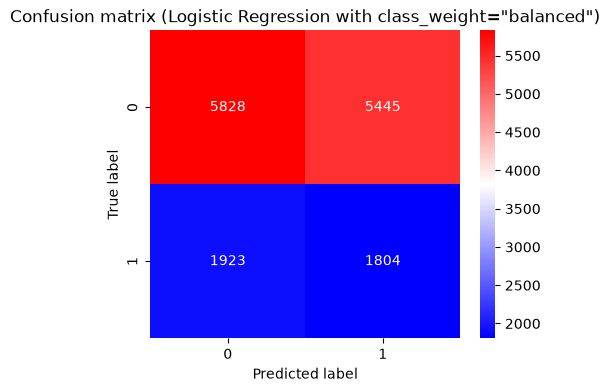

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
# Строим confusion matrix для улучшенной модели
cm_balanced = confusion_matrix(y_test_c, y_pred_balanced)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='bwr')
plt.title('Confusion matrix (Logistic Regression with class_weight="balanced")')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()